# Parameters

In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [2]:
import sys
from pathlib import Path
import pandas as pd

# ===== CONFIGURAÇÃO DE CAMINHOS =====
current_notebook = Path.cwd()  
project_root = current_notebook.parent.parent 

# Adiciona o diretório raiz ao sys.path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Agora pode importar o config
from notebooks.config import config

# Adiciona o diretório Modules ao sys.path
modules_dir = project_root / "Modules"
if str(modules_dir) not in sys.path:
    sys.path.insert(0, str(modules_dir))

# ===== IMPORTS DOS MÓDULOS =====
import Modules.ClusterHDBSCANModule as cluster
import Modules.FutureAnalysisModule as fa
from Modules.SHAPClassifierModule import *

# ===== CONFIGURAÇÕES DO PROJETO =====
DATAPATH = config["datapath"]
COVID_TRAIN_DATA_FILE = config["covid_train_data_file"]
COVID_TEST_DATA_FILE = config["covid_test_data_file"]
FUTURE_DATA_FILE = config["future_data_file"]

FIGSIZE_CLUSTER_HEATMAP = config["figsize_cluster_heatmap"]
FIGSIZE_FUTURE_HEATMAP = config["figsize_future_heatmap"]
IMAGES_SAVE_PATH = config["image_save_path"]

TRIALS_OPTUNA = 250

# Import data

In [3]:
# ===== CARREGAMENTO DOS DADOS =====
data_folder = current_notebook / DATAPATH

covid_train = pd.read_csv(data_folder / COVID_TRAIN_DATA_FILE)
covid_test = pd.read_csv(data_folder / COVID_TEST_DATA_FILE)
future_data = pd.read_csv(data_folder / FUTURE_DATA_FILE)

shap.initjs()

## Get Top features

In [4]:
features2remove = [
    "died_in_stay",
    "COVID",
    "charlson_comorbidity_index"
]  # Add the features to remove

In [5]:
helper = ShapHelperClassifier(
    covid_train.drop(columns=["subject_id", "hadm_id"]),
    covid_test.drop(columns=["subject_id", "hadm_id"]),
    "died",
)
helper.removeFeatures(features2remove)

Train size: 2348
Test size: 1007


In [6]:
param = {
    "learning_rate": 0.03194788423314631,
    "n_estimators": 855,
    "gamma": 0.15986032691615765,
    "reg_alpha": 0.7169178389895312,
    "reg_lambda": 0.5826947399857607,
    "scale_pos_weight": 12,
}

Accuracy:  0.7865
Precision: 0.5613
Recall:    0.6877
F1 Score:  0.6181


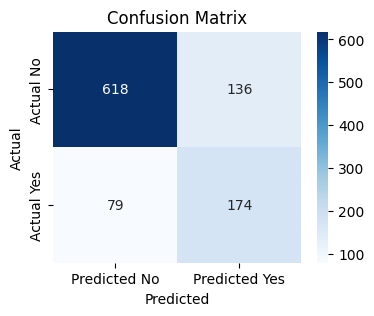

In [7]:
helper.singleModel(param, model_name="xgboost")
helper.printMetrics()
helper.showConfMatrix()

In [8]:
helper.shapConfig()

 97%|=================== | 979/1007 [00:18<00:00]       

In [9]:
features = helper.getTopFeatures(20)

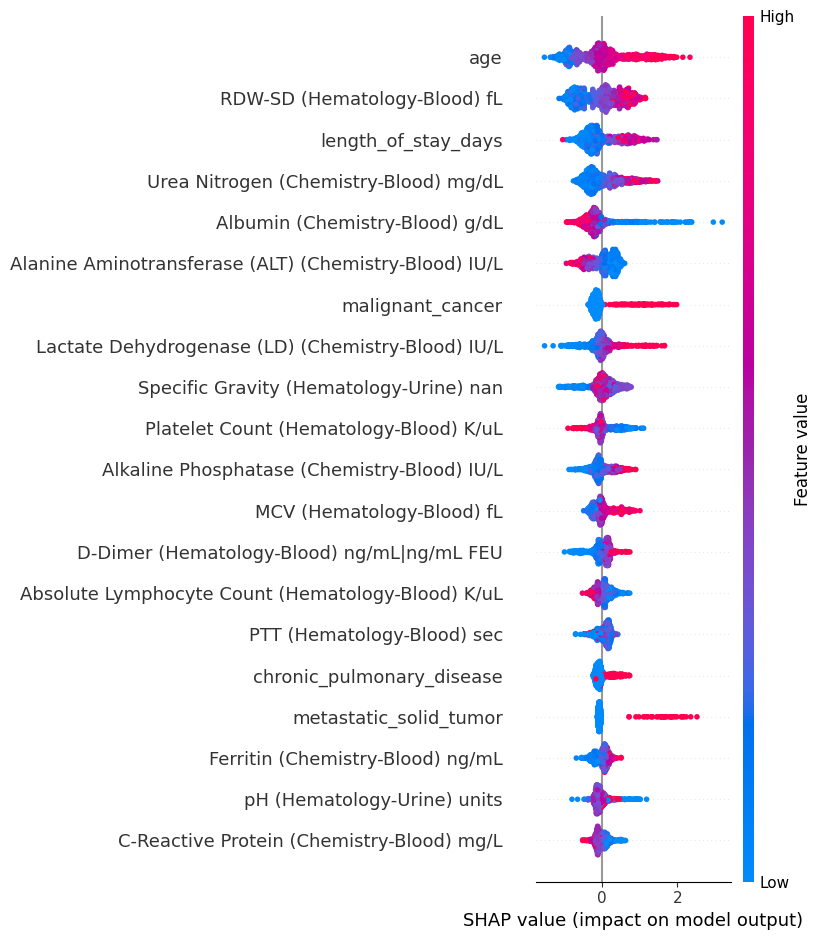

In [10]:
helper.showSummaryShap(verbose=2)

In [11]:
features

['age',
 'RDW-SD_Hematology_Blood_fL',
 'length_of_stay_days',
 'Urea Nitrogen_Chemistry_Blood_mg/dL',
 'Albumin_Chemistry_Blood_g/dL',
 'Alanine Aminotransferase (ALT)_Chemistry_Blood_IU/L',
 'malignant_cancer',
 'Lactate Dehydrogenase (LD)_Chemistry_Blood_IU/L',
 'Specific Gravity_Hematology_Urine_nan',
 'Platelet Count_Hematology_Blood_K/uL',
 'Alkaline Phosphatase_Chemistry_Blood_IU/L',
 'MCV_Hematology_Blood_fL',
 'D-Dimer_Hematology_Blood_ng/mL|ng/mL FEU',
 'Absolute Lymphocyte Count_Hematology_Blood_K/uL',
 'PTT_Hematology_Blood_sec',
 'chronic_pulmonary_disease',
 'metastatic_solid_tumor',
 'Ferritin_Chemistry_Blood_ng/mL',
 'pH_Hematology_Urine_units',
 'C-Reactive Protein_Chemistry_Blood_mg/L']

## Setup Hierarchical Clustering

In [12]:
covid_train['died_after'] = ((covid_train['died'] == 1) & (covid_train['died_in_stay'] == 0)).astype(int)
covid_test['died_after'] = ((covid_test['died'] == 1) & (covid_test['died_in_stay'] == 0)).astype(int)
future_data['died_after'] = ((future_data['died'] == 1) & (future_data['died_in_stay'] == 0)).astype(int)

In [13]:
data_covid = pd.concat([covid_train, covid_test], axis=0)
data_covid = data_covid.sample(frac=1, random_state=42).reset_index(drop=True)

In [14]:
featuresNotConsidered = [x for x in data_covid.columns.tolist() if x not in features]

In [15]:
helper = cluster.HDBSCANClusterHelper(data=data_covid, featuresNotConsidered=featuresNotConsidered)

## Find best hyperparameters for DBSCAN - cluster_selection_method: 'eom'

In [16]:
param = {
    "min_cluster_size": {"min": 5, "max": 30},
    "min_samples": {"min": 1, "max": 20}
}

### DBCV

In [17]:
os.environ["PYTHONWARNINGS"] = "ignore"
dbcv_df, dbcv_param, dbcv_best = helper.optunaGridSearch(
    parameters=param, 
    n_trials=TRIALS_OPTUNA, 
    saveStorage=True, 
    metric="dbcv",
    restrictMinsizeCluster=2,
    restrictMaxsizeCluster=80,
    suffix="death"
)

[I 2026-01-15 17:29:10,145] A new study created in RDB with name: Optuna Study HDBSCAN Death DBCV 0
[I 2026-01-15 17:29:10,339] Trial 0 finished with value: -2.0 and parameters: {'min_cluster_size': 18, 'min_samples': 20}. Best is trial 0 with value: -2.0.
[I 2026-01-15 17:29:10,527] Trial 1 finished with value: -3.0 and parameters: {'min_cluster_size': 9, 'min_samples': 3}. Best is trial 0 with value: -2.0.
[I 2026-01-15 17:29:10,710] Trial 2 finished with value: -2.0 and parameters: {'min_cluster_size': 24, 'min_samples': 19}. Best is trial 0 with value: -2.0.
[I 2026-01-15 17:29:10,881] Trial 3 finished with value: -2.0 and parameters: {'min_cluster_size': 26, 'min_samples': 16}. Best is trial 0 with value: -2.0.
[I 2026-01-15 17:29:11,056] Trial 4 finished with value: -2.0 and parameters: {'min_cluster_size': 21, 'min_samples': 17}. Best is trial 0 with value: -2.0.
[I 2026-01-15 17:29:11,322] Trial 5 finished with value: -3.0 and parameters: {'min_cluster_size': 18, 'min_samples':


Best parameters: {'min_cluster_size': 7, 'min_samples': 1}
Best DBCV score: 0.7975805313014505



### DISCO

In [18]:
os.environ['PYTHONWARNINGS'] = 'ignore'
disco_df, disco_param, disco_best = helper.optunaGridSearch(
    parameters=param, 
    n_trials=TRIALS_OPTUNA, 
    saveStorage=True, 
    metric="disco",
    restrictMinsizeCluster=2,
    restrictMaxsizeCluster=80,
    suffix="death"
)

[I 2026-01-15 17:35:17,239] A new study created in RDB with name: Optuna Study HDBSCAN Death DISCO 0
[I 2026-01-15 17:35:17,420] Trial 0 finished with value: -2.0 and parameters: {'min_cluster_size': 8, 'min_samples': 14}. Best is trial 0 with value: -2.0.
[I 2026-01-15 17:35:17,608] Trial 1 finished with value: -2.0 and parameters: {'min_cluster_size': 20, 'min_samples': 20}. Best is trial 0 with value: -2.0.
[I 2026-01-15 17:35:17,782] Trial 2 finished with value: -2.0 and parameters: {'min_cluster_size': 25, 'min_samples': 16}. Best is trial 0 with value: -2.0.
[I 2026-01-15 17:35:17,973] Trial 3 finished with value: -2.0 and parameters: {'min_cluster_size': 9, 'min_samples': 18}. Best is trial 0 with value: -2.0.
[I 2026-01-15 17:35:18,156] Trial 4 finished with value: -3.0 and parameters: {'min_cluster_size': 8, 'min_samples': 4}. Best is trial 0 with value: -2.0.
[I 2026-01-15 17:35:18,342] Trial 5 finished with value: -2.0 and parameters: {'min_cluster_size': 25, 'min_samples': 


Best parameters: {'min_cluster_size': 7, 'min_samples': 1}
Best DISCO score: 0.16422895648705105



### DSI

In [19]:
os.environ['PYTHONWARNINGS'] = 'ignore'
dsi_df, dsi_param, dsi_best = helper.optunaGridSearch(
    parameters=param, 
    n_trials=TRIALS_OPTUNA, 
    saveStorage=True, 
    metric="dsi",
    restrictMinsizeCluster=2,
    restrictMaxsizeCluster=80,
    suffix="death"
)

[I 2026-01-15 17:36:45,761] A new study created in RDB with name: Optuna Study HDBSCAN Death DSI 0
[I 2026-01-15 17:36:45,943] Trial 0 finished with value: -2.0 and parameters: {'min_cluster_size': 19, 'min_samples': 12}. Best is trial 0 with value: -2.0.
[I 2026-01-15 17:36:46,116] Trial 1 finished with value: -2.0 and parameters: {'min_cluster_size': 30, 'min_samples': 10}. Best is trial 0 with value: -2.0.
[I 2026-01-15 17:36:46,300] Trial 2 finished with value: -2.0 and parameters: {'min_cluster_size': 25, 'min_samples': 5}. Best is trial 0 with value: -2.0.
[I 2026-01-15 17:36:46,484] Trial 3 finished with value: -3.0 and parameters: {'min_cluster_size': 10, 'min_samples': 5}. Best is trial 0 with value: -2.0.
[I 2026-01-15 17:36:46,676] Trial 4 finished with value: -3.0 and parameters: {'min_cluster_size': 5, 'min_samples': 18}. Best is trial 0 with value: -2.0.
[I 2026-01-15 17:36:46,861] Trial 5 finished with value: -2.0 and parameters: {'min_cluster_size': 9, 'min_samples': 20


Best parameters: {'min_cluster_size': 19, 'min_samples': 12}
Best DSI score: -2.0



### Silhouette

In [20]:
os.environ['PYTHONWARNINGS'] = 'ignore'
silhouette_df, silhouette_param, silhouette_best = helper.optunaGridSearch(
    parameters=param, 
    n_trials=TRIALS_OPTUNA, 
    saveStorage=True, 
    metric="silhouette",
    restrictMinsizeCluster=2,
    restrictMaxsizeCluster=80,
    suffix="death"
)

[I 2026-01-15 17:37:31,523] A new study created in RDB with name: Optuna Study HDBSCAN Death SILHOUETTE 0
[I 2026-01-15 17:37:31,698] Trial 0 finished with value: -3.0 and parameters: {'min_cluster_size': 8, 'min_samples': 6}. Best is trial 0 with value: -3.0.
[I 2026-01-15 17:37:31,872] Trial 1 finished with value: -2.0 and parameters: {'min_cluster_size': 9, 'min_samples': 14}. Best is trial 1 with value: -2.0.
[I 2026-01-15 17:37:32,045] Trial 2 finished with value: -2.0 and parameters: {'min_cluster_size': 13, 'min_samples': 8}. Best is trial 1 with value: -2.0.
[I 2026-01-15 17:37:32,218] Trial 3 finished with value: -2.0 and parameters: {'min_cluster_size': 10, 'min_samples': 12}. Best is trial 1 with value: -2.0.
[I 2026-01-15 17:37:32,392] Trial 4 finished with value: -2.0 and parameters: {'min_cluster_size': 16, 'min_samples': 8}. Best is trial 1 with value: -2.0.
[I 2026-01-15 17:37:32,564] Trial 5 finished with value: -2.0 and parameters: {'min_cluster_size': 13, 'min_sample


Best parameters: {'min_cluster_size': 9, 'min_samples': 1}
Best SILHOUETTE score: -0.179



### Metrics

In [21]:
helper.clustering(
    min_cluster_size=dbcv_param["min_cluster_size"],
    min_samples=dbcv_param["min_samples"],
)
helper.getMetrics()

{'silhouette': -0.216,
 'dbcv': 0.7975805313014505,
 'dsi': np.float64(0.249),
 'disco': np.float64(0.16422895648705105)}

In [22]:
helper.clustering(
    min_cluster_size=disco_param["min_cluster_size"],
    min_samples=disco_param["min_samples"],
)
helper.getMetrics()

{'silhouette': -0.216,
 'dbcv': 0.7975805313014505,
 'dsi': np.float64(0.249),
 'disco': np.float64(0.16422895648705105)}

In [23]:
helper.clustering(
    min_cluster_size=dsi_param["min_cluster_size"],
    min_samples=dsi_param["min_samples"],
)
helper.getMetrics()

{'silhouette': -1, 'dbcv': 0.0, 'dsi': 0, 'disco': np.float64(-1.0)}

In [24]:
helper.clustering(
    min_cluster_size=silhouette_param["min_cluster_size"],
    min_samples=silhouette_param["min_samples"],
)
helper.getMetrics()

{'silhouette': -0.179,
 'dbcv': 0.5007449236478498,
 'dsi': np.float64(0.177),
 'disco': np.float64(-0.23311617780831248)}

## Best Result - DBCV

In [26]:
best_param = dbcv_param

In [27]:
helper.clustering(
    min_cluster_size=best_param["min_cluster_size"],
    min_samples=best_param["min_samples"],
)
helper.getMetrics()

{'silhouette': -0.216,
 'dbcv': 0.7975805313014505,
 'dsi': np.float64(0.249),
 'disco': np.float64(0.16422895648705105)}

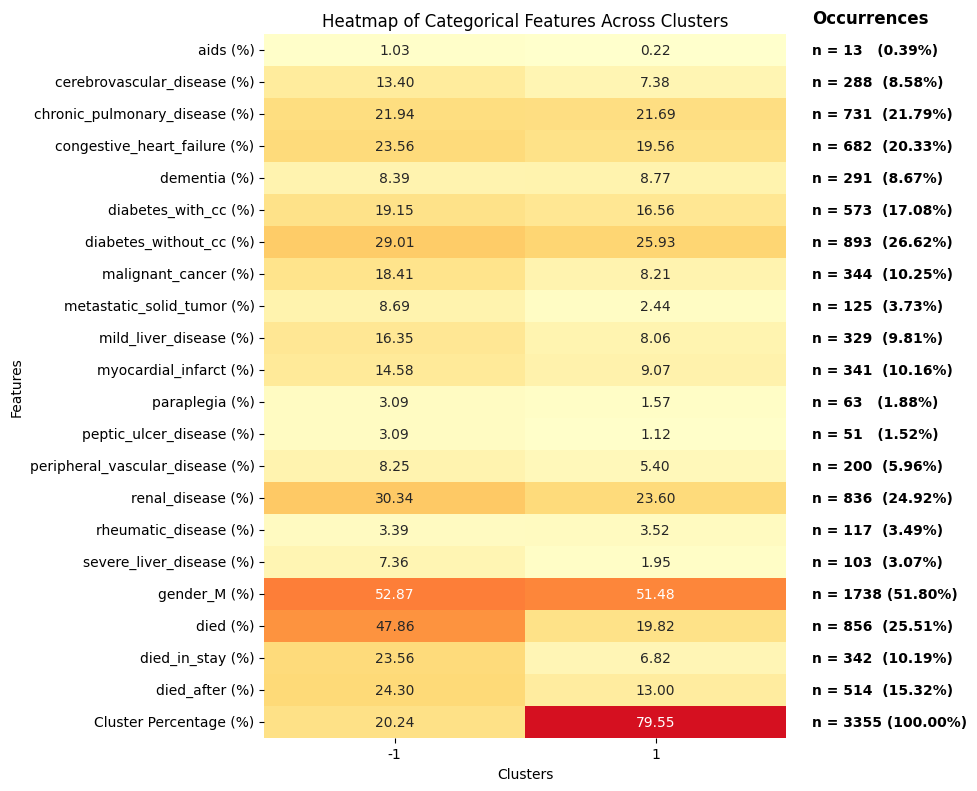

In [28]:
helper.heatmapClustersCategorical(
    figsize=FIGSIZE_CLUSTER_HEATMAP,
    savepath=IMAGES_SAVE_PATH + "hdbscan-death-categorical"
)

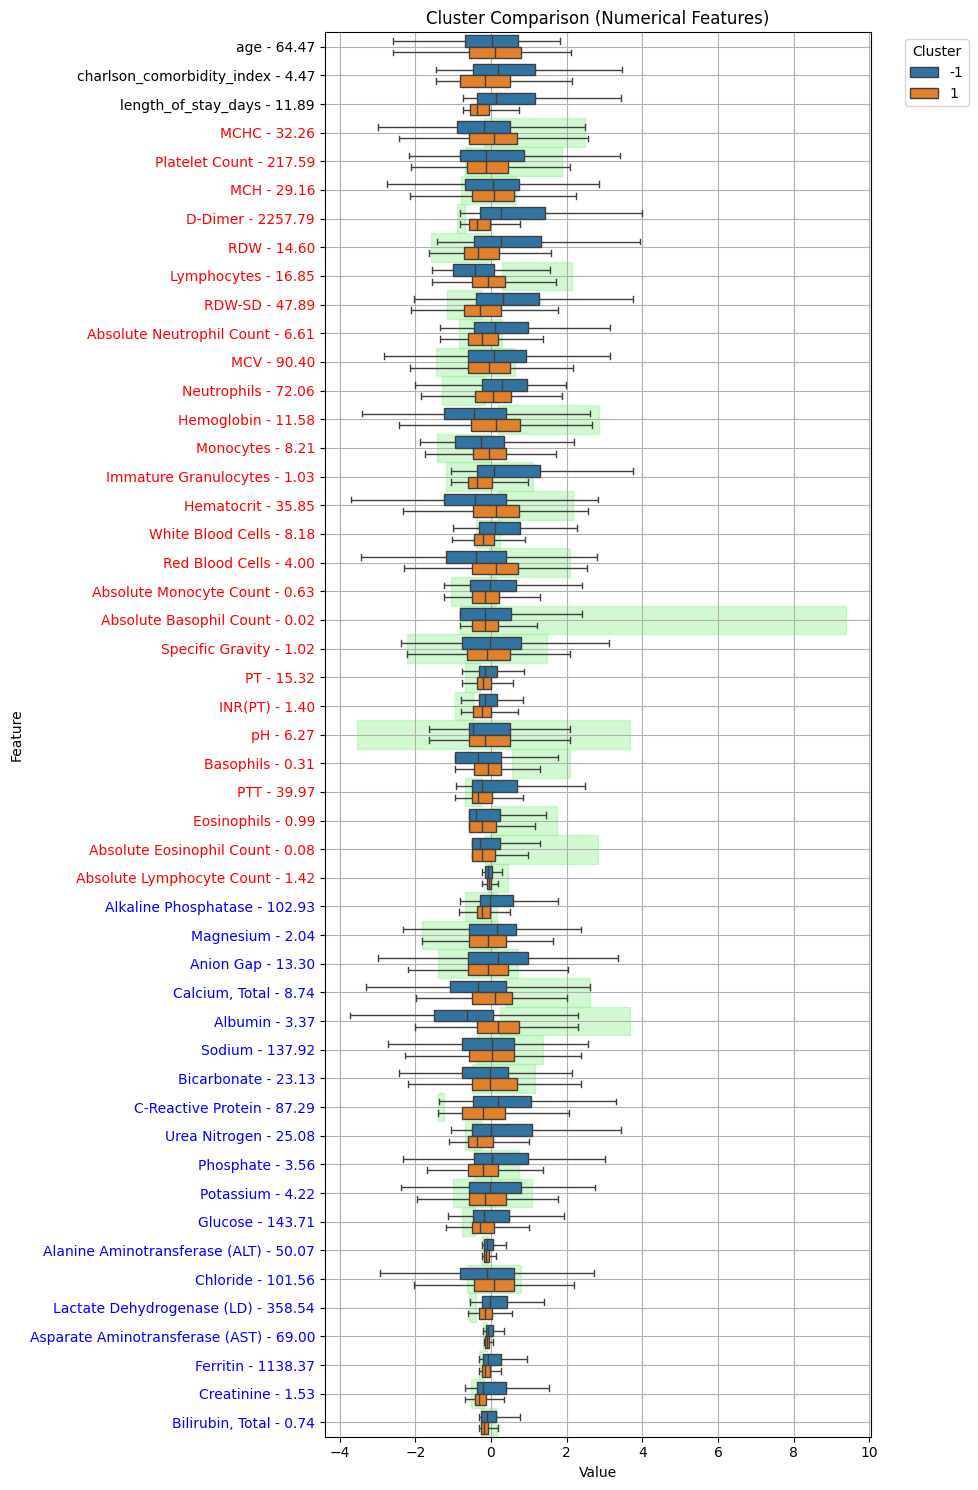

[]

In [29]:
helper.showClusterCompareNumerical(
    scaled="standard",
    topFeatures=-1,
    max_features=-1,
    figsize=(10, 15),
    savepath=IMAGES_SAVE_PATH + "hdbscan-death-numerical"
)

In [30]:
selectedClusters = [-1, 1]

In [31]:
helper.setClusteredAutoencoder()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:24<00:00,  4.01it/s]


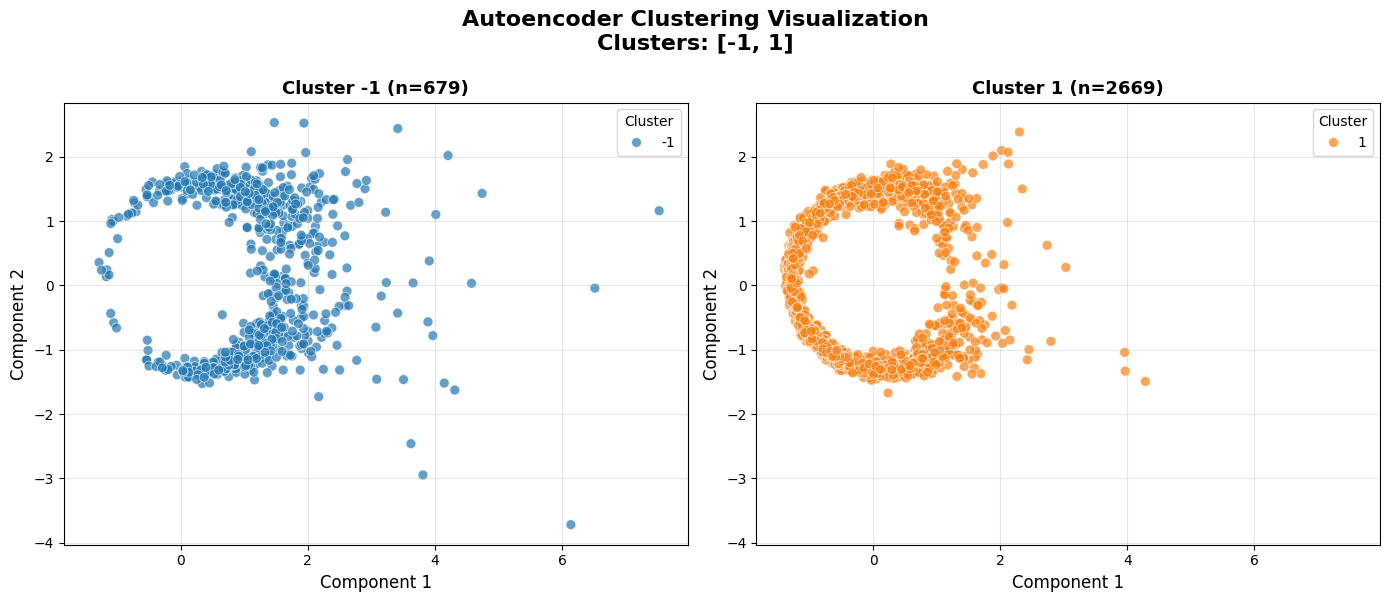

In [32]:
helper.showClusteredAutoencoder(selectedClusters=selectedClusters, savepath=IMAGES_SAVE_PATH + "hdbscan-autoencoder-death")

##### Future data


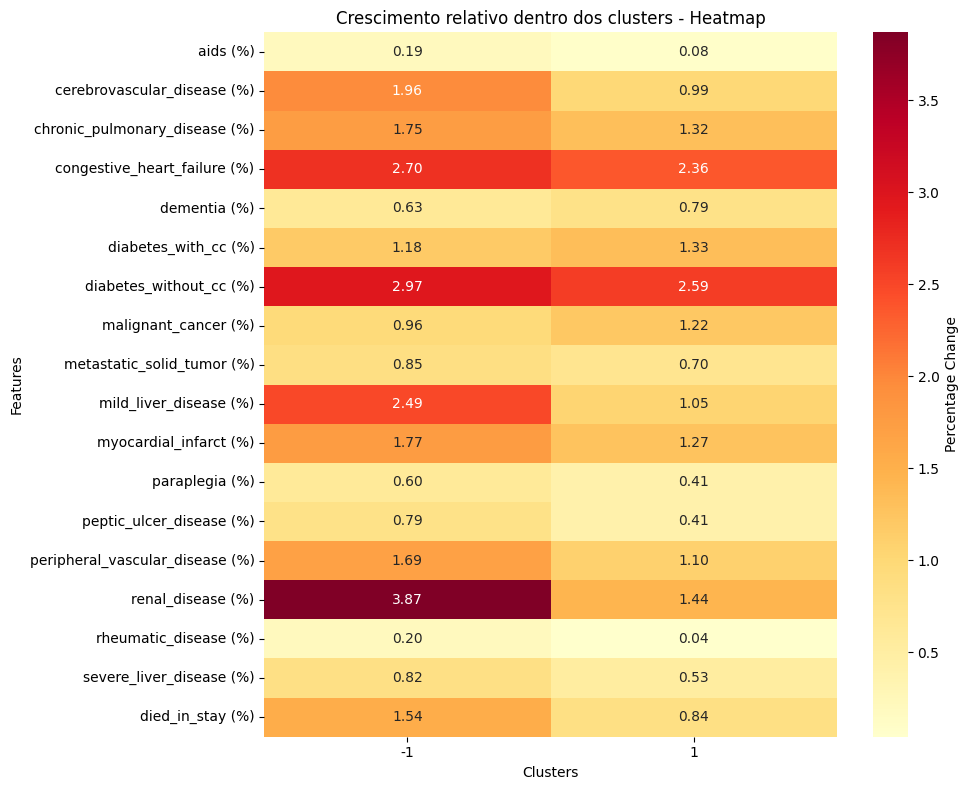

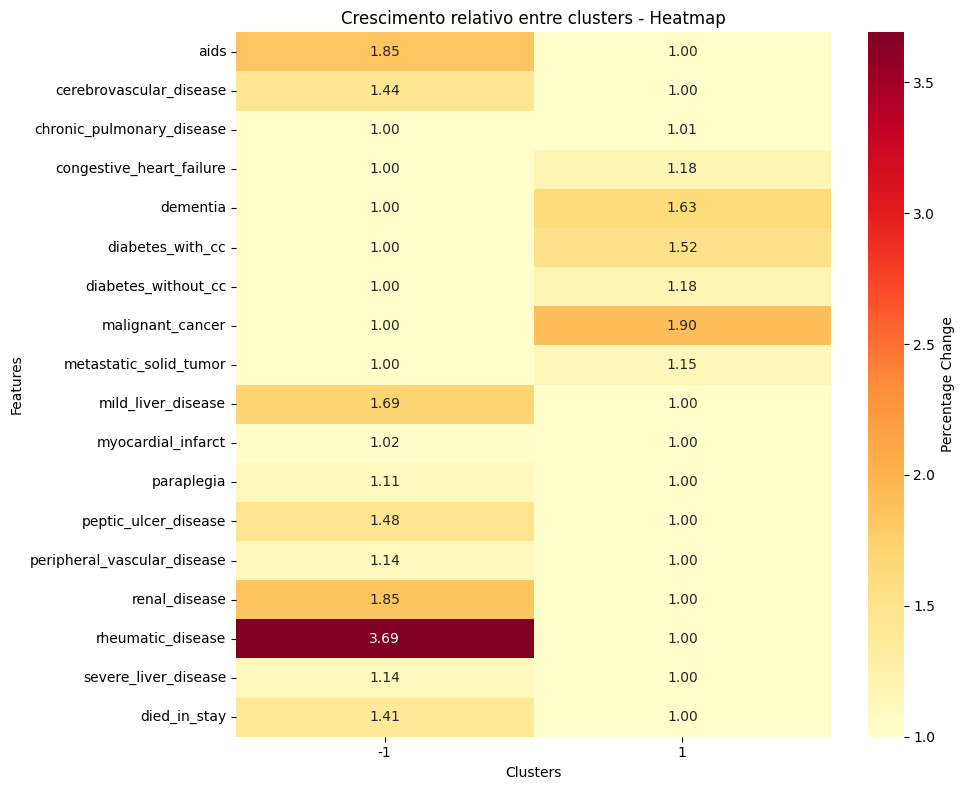

In [33]:
future_helper = fa.FutureAnalysisHelper(helper.clusteredData, future_data)
future_helper.insertClustersInFutureData(onlyFirstAdmission=True)
delta = future_helper.getDeltaClusters(percentage=True, metric="interno")
future_helper.showDeltaHeatmap(
    figsize=FIGSIZE_FUTURE_HEATMAP,
    savepath=IMAGES_SAVE_PATH + "hdbscan-death-dbcv-eom-interno", selectedClusters=selectedClusters,
    metric="interno"
)
delta = future_helper.getDeltaClusters(percentage=True, metric="externo")
future_helper.showDeltaHeatmap(
    figsize=FIGSIZE_FUTURE_HEATMAP,
    savepath=IMAGES_SAVE_PATH + "hdbscan-death-dbcv-eom-externo", selectedClusters=selectedClusters,
    metric="externo"
)

In [34]:
future_helper.getMeanReadmission()

{'Mean readmission Cluster -1': 2.42,
 'Mean readmission Cluster 0': 4.8,
 'Mean readmission Cluster 1': 2.27,
 'Overall Mean readmission': 2.31}

In [35]:
future_helper.getMeanDaysGap()

{'Mean days gap Cluster -1': 114.28,
 'Mean days gap Cluster 0': 202.99,
 'Mean days gap Cluster 1': 130.57,
 'Overall Mean days gap': 127.49}

In [36]:
future_helper.getMortalityRates(onlyFirstAdmission=True)

{'Mortality rate Cluster -1': 0.05,
 'Mortality rate Cluster 0': 0.0,
 'Mortality rate Cluster 1': 0.12,
 'Overall Mortality rate': 0.09}

### Add Log

In [37]:
log_file = "../log.csv"
current_dir = os.getcwd()
log_file_path = os.path.join(current_dir, log_file)

metrics = helper.getMetrics()

# Add line to save log
if os.path.exists(log_file_path):
    with open(log_file_path, 'a') as f:
        f.write(f"HDBSCAN, Shap, Comprehensive, {metrics['disco']}, {metrics['dbcv']}, {metrics['dsi']}, {metrics['silhouette']}\n")